In [1]:
!pip install pandasgwas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasgwas import get_associations

print("Environment successfully configured with dependencies.")

Defaulting to user installation because normal site-packages is not writeable
Environment successfully configured with dependencies.


In [2]:
# Target traits representing the core focus of this study
diseases = ["Alzheimer disease", "Parkinson disease", "amyotrophic lateral sclerosis"]

raw_records = []

for disease in diseases:
    print(f" System connecting to GWAS Catalog API for: {disease}...")
    try:
        # Fetching raw data with interactive=False to bypass command-line prompts
        results = get_associations(efo_trait=disease, interactive=False)
        df_raw = results.associations

        if df_raw is not None and not df_raw.empty:
            # Tag the raw data rows with the originating trait for trackability
            df_raw['Target_Disease'] = disease
            raw_records.append(df_raw)
            print(f"   ↳ Extracted {len(df_raw)} raw association rows for {disease}.")
    except Exception as e:
        print(f" API Retrieval Error for {disease}: {e}")

# Consolidate raw data into an initial audit trail
if raw_records:
    df_all_raw = pd.concat(raw_records, ignore_index=True)
    df_all_raw.to_csv("Step1_A_Raw_GWAS_Associations.csv", index=False)
    print("\n" + "="*40)
    print(" INITIAL DATA POOL COLLECTED")
    print(f"Total raw clinical association rows mapped: {len(df_all_raw)}")
    print("="*40)
    print(df_all_raw['Target_Disease'].value_counts())
else:
    print(" Critical Failure: No raw data returned from the GWAS Catalog.")

 System connecting to GWAS Catalog API for: Alzheimer disease...
   ↳ Extracted 6214 raw association rows for Alzheimer disease.
 System connecting to GWAS Catalog API for: Parkinson disease...
   ↳ Extracted 792 raw association rows for Parkinson disease.
 System connecting to GWAS Catalog API for: amyotrophic lateral sclerosis...
   ↳ Extracted 169 raw association rows for amyotrophic lateral sclerosis.

 INITIAL DATA POOL COLLECTED
Total raw clinical association rows mapped: 7175
Target_Disease
Alzheimer disease                6214
Parkinson disease                 792
amyotrophic lateral sclerosis     169
Name: count, dtype: int64


In [3]:
# Strict, universally recognized genome-wide statistical significance threshold
P_VALUE_THRESHOLD = 5e-8

filtered_snps = []

print(f" Applying statistical filter (p-value <= {P_VALUE_THRESHOLD})...")

# Loop through our consolidated raw dataset
for index, row in df_all_raw.iterrows():
    p_val = row['pvalue']
    disease = row['Target_Disease']
    
    # Filter out weak associations to isolate high-confidence disease drivers
    if p_val <= P_VALUE_THRESHOLD:
        # Drill down into nested JSON genomic structures returned by the API
        if isinstance(row['loci'], list):
            for locus in row['loci']:
                if 'strongestRiskAlleles' in locus and isinstance(locus['strongestRiskAlleles'], list):
                    for allele_info in locus['strongestRiskAlleles']:
                        full_name = allele_info.get('riskAlleleName') # e.g., "rs6678275-C"

                        if full_name:
                            # Parse out only the core rsID prefix, removing structural trailing base letters
                            rsid = full_name.split('-')[0].strip()

                            if rsid.startswith('rs'):
                                filtered_snps.append({
                                    'rsid': rsid,
                                    'p_value': p_val,
                                    'Disease': disease
                                })

# Convert filtered results into a tracking dataframe
if filtered_snps:
    df_filtered = pd.DataFrame(filtered_snps)
    print("\n" + "="*40)
    print(" FILTER STAGE 1 COMPLETE")
    print(f"Total significant hits passing p-value filter: {len(df_filtered)}")
    print("="*40)
    print(df_filtered['Disease'].value_counts())
else:
    print(" No variants met the genome-wide significance threshold.")

 Applying statistical filter (p-value <= 5e-08)...

 FILTER STAGE 1 COMPLETE
Total significant hits passing p-value filter: 3731
Disease
Alzheimer disease                3145
Parkinson disease                 518
amyotrophic lateral sclerosis      68
Name: count, dtype: int64


In [4]:
if 'df_filtered' in locals() and not df_filtered.empty:
    # Drop duplicates where the exact same variant is linked to the same disease multiple times
    final_df = df_filtered.drop_duplicates(subset=['rsid', 'Disease'])

    # Export finalized experimental test suite as a clean checkpoint file
    final_df.to_csv("Step1_Significant_SNPs.csv", index=False)

    print("\n" + "="*40)
    print(" STEP 1 COMPLETED: FINAL TEST SUITE")
    print(f"Total unique, high-confidence risk variants isolated: {len(final_df)}")
    print("="*40)
    print(final_df['Disease'].value_counts())
    print("\n Displaying top preview rows:")
    print(final_df.head())
else:
    print(" No data available for deduplication. Run preceding cells.")


 STEP 1 COMPLETED: FINAL TEST SUITE
Total unique, high-confidence risk variants isolated: 2788
Disease
Alzheimer disease                2371
Parkinson disease                 373
amyotrophic lateral sclerosis      44
Name: count, dtype: int64

 Displaying top preview rows:
      rsid       p_value       Disease      
0   rs4420638  8.000e-149  Alzheimer disease
1  rs59007384   7.000e-09  Alzheimer disease
2      rs6857   1.000e-10  Alzheimer disease
3  rs56131196   4.000e-12  Alzheimer disease
4    rs429358   5.000e-14  Alzheimer disease


 Figure successfully exported at 300 DPI: 'Thesis_Step1_Data_Funnel_Profile.png'


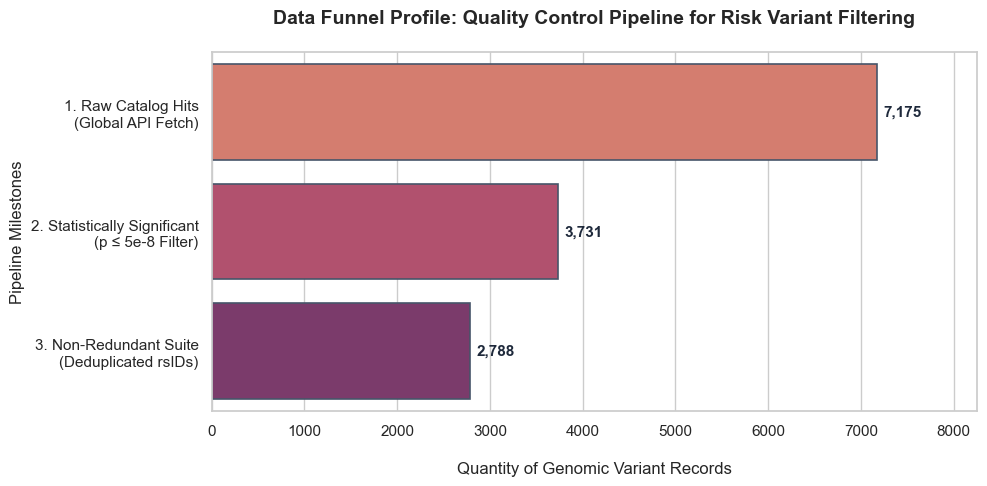

In [5]:
# Setup professional scientific plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

# Generate counts across the sequential operational stages
raw_count = len(df_all_raw) if 'df_all_raw' in locals() else 0
filtered_count = len(df_filtered) if 'df_filtered' in locals() else 0
final_count = len(final_df) if 'final_df' in locals() else 0

stages_data = pd.DataFrame({
    'Computational Stage': [
        '1. Raw Catalog Hits\n(Global API Fetch)', 
        '2. Statistically Significant\n(p ≤ 5e-8 Filter)', 
        '3. Non-Redundant Suite\n(Deduplicated rsIDs)'
    ],
    'Total Variant Counts': [raw_count, filtered_count, final_count]
})

fig, ax = plt.subplots(figsize=(10, 5))

# Generate structural step chart profile
sns.barplot(
    x='Total Variant Counts',
    y='Computational Stage',
    hue='Computational Stage',
    data=stages_data,
    palette='flare',
    edgecolor='#475569',
    linewidth=1.2,
    legend=False,
    ax=ax
)

# Render explicit count tags at the tip of each bar for automated data transparency
for index, value in enumerate(stages_data['Total Variant Counts']):
    ax.text(
        value + (max(stages_data['Total Variant Counts']) * 0.01), 
        index, 
        f"{value:,}", 
        va='center', 
        fontweight='bold', 
        color='#1e293b',
        fontsize=11
    )

ax.set_title("Data Funnel Profile: Quality Control Pipeline for Risk Variant Filtering\n", weight='bold', fontsize=14)
ax.set_xlabel("\nQuantity of Genomic Variant Records", fontsize=12)
ax.set_ylabel("Pipeline Milestones", fontsize=12)
ax.set_xlim(0, max(stages_data['Total Variant Counts']) * 1.15)

plt.tight_layout()
plt.savefig("Thesis_Step1_Data_Funnel_Profile.png", dpi=300, bbox_inches='tight')
print(" Figure successfully exported at 300 DPI: 'Thesis_Step1_Data_Funnel_Profile.png'")
plt.show()

In [6]:
print(type(results))
print([a for a in dir(results) if not a.startswith('_')])
print("associations columns:", list(df_all_raw.columns))
print(df_all_raw[['pvalue']].head() if 'pvalue' in df_all_raw.columns else "NO pvalue column")
# does a nested loci column actually exist?
print("loci in columns?", 'loci' in df_all_raw.columns)

<class 'pandasgwas.Association.Association'>
['associations', 'author_reported_genes', 'ensembl_gene_ids', 'entrez_gene_ids', 'loci', 'parse', 'raw_data', 'strongest_risk_alleles']
associations columns: ['riskFrequency', 'pvalueDescription', 'pvalueMantissa', 'pvalueExponent', 'multiSnpHaplotype', 'snpInteraction', 'snpType', 'standardError', 'range', 'description', 'orPerCopyNum', 'betaNum', 'betaUnit', 'betaDirection', 'loci', 'lastMappingDate', 'lastUpdateDate', 'pvalue', 'associationId', 'Target_Disease']
    pvalue  
0  3.000e-07
1  7.000e-08
2  7.000e-07
3  6.000e-07
4  8.000e-08
loci in columns? True


In [7]:
import requests
from datetime import datetime, timezone

DISEASE_CONFIG = {
    "Alzheimer disease":             "EFO_0000249",
    "Parkinson disease":             "EFO_0002508",
    "amyotrophic lateral sclerosis": "EFO_0000253",
}

P_VALUE_THRESHOLD = 5e-8  # standard genome-wide significance

# Record WHEN accessed the catalog and WHICH release it was.
ACCESS_TIMESTAMP = datetime.now(timezone.utc).isoformat()
catalog_release = "UNKNOWN"
try:
    meta = requests.get("https://www.ebi.ac.uk/gwas/api/metadata", timeout=30).json()
    catalog_release = meta 
except Exception as e:
    print("Could not fetch catalog metadata automatically:", e)

print("GWAS Catalog accessed (UTC):", ACCESS_TIMESTAMP)
print("Catalog release metadata:", catalog_release)

Could not fetch catalog metadata automatically: Expecting value: line 1 column 1 (char 0)
GWAS Catalog accessed (UTC): 2026-06-14T06:12:10.566055+00:00
Catalog release metadata: UNKNOWN


In [8]:
from pandasgwas import get_associations
import pandas as pd

raw_records = []
for trait_name, efo_id in DISEASE_CONFIG.items():
    print(f"Querying GWAS Catalog: {trait_name} ({efo_id})...")
    try:
        results = get_associations(efo_id=efo_id, interactive=False)
        df_raw = results.associations
        if df_raw is not None and not df_raw.empty:
            df_raw = df_raw.copy()
            df_raw["Target_Disease"] = trait_name
            df_raw["EFO_ID"] = efo_id
            raw_records.append(df_raw)
            print(f"   -> {len(df_raw)} associations")
    except Exception as e:
        print(f"   ERROR for {trait_name}: {e}")

df_all_raw = pd.concat(raw_records, ignore_index=True)
df_all_raw.to_csv("(1)Step1_A_Raw_GWAS_Associations.csv", index=False)
print("Total raw associations:", len(df_all_raw))
print(df_all_raw["Target_Disease"].value_counts())

Querying GWAS Catalog: Alzheimer disease (EFO_0000249)...
Querying GWAS Catalog: Parkinson disease (EFO_0002508)...
Querying GWAS Catalog: amyotrophic lateral sclerosis (EFO_0000253)...


ValueError: No objects to concatenate